# Bridgeport Notebook 11 -- Score-Readiness Integration (pre-score gate)

## Purpose

The user has authorized moving to Phase 3 pilot scoring, conditioned on one narrowly scoped
additive integration step first: (1) register the Small General scenario that Notebook 10 found
missing from the Phase-2 scenario registry, and (2) merge Notebook 10's V7, V12, and PARKING
(V5-relevant) evidence into the score-readiness layer. This is **not** another open-ended recovery
pass -- registry gaps beyond Small General are documented but intentionally left out of scope here.

This notebook does exactly five things, matching the user's specification:

1. Patch Small General additively (new addendum file; baseline registry untouched).
2. Merge Notebook 10's V7/V12 master-use-table evidence and the completed 13-page PARKING family
   (V5-relevant) into the scenario-level evidence layer.
3. Recompute availability/comparability/score-readiness classifications at the scenario grain, using
   the explicit status vocabulary the user specified.
4. Construct an explicit score-eligibility universe of Bridgeport scenarios, with a pre-declared,
   mechanically applied inclusion rule and a stated reason for every exclusion.
5. Freeze a versioned, hashed scoring-input file. **No score is computed in this notebook.**

All outputs are new, additively named files. No existing baseline file is modified in place; this is
verified by byte-hash comparison in the final validation section.


In [1]:
import pandas as pd
import numpy as np
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone

STAGE_A_ROOT = Path("/Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader")
PROCESSED_DIR = STAGE_A_ROOT / "data" / "processed"
BPT_PROCESSED = PROCESSED_DIR / "bridgeport"
TABLES_DIR = STAGE_A_ROOT / "outputs" / "tables"
REVIEW_DIR = STAGE_A_ROOT / "outputs" / "review" / "bridgeport"
LOGS_DIR = STAGE_A_ROOT / "outputs" / "logs" / "bridgeport"
FIGURES_DIR = STAGE_A_ROOT / "outputs" / "figures" / "bridgeport"
for d in [REVIEW_DIR, LOGS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat()

BASELINE_FILES = {
    "bridgeport_all_district_scenarios.parquet": BPT_PROCESSED / "bridgeport_all_district_scenarios.parquet",
    "fixed_variable_recovery_matrix_bridgeport_greenwich.csv": PROCESSED_DIR / "fixed_variable_recovery_matrix_bridgeport_greenwich.csv",
    "expanded_variable_recovery_matrix_bridgeport_greenwich.csv": PROCESSED_DIR / "expanded_variable_recovery_matrix_bridgeport_greenwich.csv",
    "expanded_variable_score_readiness.csv": PROCESSED_DIR / "expanded_variable_score_readiness.csv",
    "expanded_variable_dependency_map.csv": PROCESSED_DIR / "expanded_variable_dependency_map.csv",
    "expanded_variable_scoring_rubrics_draft.csv": PROCESSED_DIR / "expanded_variable_scoring_rubrics_draft.csv",
    "expanded_variable_registry_v1.csv": PROCESSED_DIR / "expanded_variable_registry_v1.csv",
    "bridgeport_v7_v12_master_use_table_addendum.csv": PROCESSED_DIR / "bridgeport_v7_v12_master_use_table_addendum.csv",
    "bridgeport_parking_full_13_building_type_recovery.csv": PROCESSED_DIR / "bridgeport_parking_full_13_building_type_recovery.csv",
}
BASELINE_HASHES = {name: hashlib.sha256(p.read_bytes()).hexdigest() for name, p in BASELINE_FILES.items()}

scenarios_baseline = pd.read_parquet(BASELINE_FILES["bridgeport_all_district_scenarios.parquet"])
fixed_matrix = pd.read_csv(BASELINE_FILES["fixed_variable_recovery_matrix_bridgeport_greenwich.csv"])
expanded_matrix = pd.read_csv(BASELINE_FILES["expanded_variable_recovery_matrix_bridgeport_greenwich.csv"])
score_readiness_baseline = pd.read_csv(BASELINE_FILES["expanded_variable_score_readiness.csv"])
dependency_map = pd.read_csv(BASELINE_FILES["expanded_variable_dependency_map.csv"])
scoring_rubrics_draft = pd.read_csv(BASELINE_FILES["expanded_variable_scoring_rubrics_draft.csv"])
variable_registry = pd.read_csv(BASELINE_FILES["expanded_variable_registry_v1.csv"])
v7_v12_addendum = pd.read_csv(BASELINE_FILES["bridgeport_v7_v12_master_use_table_addendum.csv"])
parking_full_13 = pd.read_csv(BASELINE_FILES["bridgeport_parking_full_13_building_type_recovery.csv"])

print(f"Run timestamp: {RUN_TIMESTAMP}")
print(f"Baseline scenario registry: {len(scenarios_baseline)} rows")
print(f"V7/V12 addendum (Notebook 10): {len(v7_v12_addendum)} rows")
print(f"PARKING full-13 recovery (Notebook 10): {len(parking_full_13)} rows")
print(f"Fixed variable matrix: {len(fixed_matrix)} rows (read-only reference)")
print(f"Expanded variable matrix: {len(expanded_matrix)} rows (read-only reference)")

Run timestamp: 2026-10-01T20:37:44.729194+00:00
Baseline scenario registry: 46 rows
V7/V12 addendum (Notebook 10): 100 rows
PARKING full-13 recovery (Notebook 10): 49 rows
Fixed variable matrix: 360 rows (read-only reference)
Expanded variable matrix: 460 rows (read-only reference)


## Section 1 -- Patch 1: Small General scenario registry addendum

Adds the two real, evidence-backed Small General scenarios (zones NX2 and RX1, section 3.60, pages
56-57) found during Notebook 10's master-use-table transcription. Written as a **new** file;
`bridgeport_all_district_scenarios.parquet` is not opened for writing anywhere in this notebook.


In [2]:
existing_scenario_ids = scenarios_baseline["scenario_id"].tolist()
max_scenario_num = max(int(sid.split("-")[-1]) for sid in existing_scenario_ids)

SMALL_GENERAL_ADDENDUM_RECORDS = [
    {"district_code": "NX2", "building_form_or_type": "Small General", "frontage_or_site_condition": None,
     "scenario_id": f"bridgeport-scenario-{max_scenario_num + 1:04d}", "district_name": None,
     "classification": "mixed_use_residential_capable", "use_type": None, "source_pages": [56, 57],
     "evidence_confidence": 0.95, "review_status": "post_phase_2_registry_addendum",
     "scenario_source": "post_phase_2_registry_addendum"},
    {"district_code": "RX1", "building_form_or_type": "Small General", "frontage_or_site_condition": None,
     "scenario_id": f"bridgeport-scenario-{max_scenario_num + 2:04d}", "district_name": None,
     "classification": "mixed_use_residential_capable", "use_type": None, "source_pages": [56, 57],
     "evidence_confidence": 0.95, "review_status": "post_phase_2_registry_addendum",
     "scenario_source": "post_phase_2_registry_addendum"},
]
small_general_registry_addendum_df = pd.DataFrame(SMALL_GENERAL_ADDENDUM_RECORDS)
small_general_registry_addendum_df["date_version"] = RUN_TIMESTAMP

print(small_general_registry_addendum_df[["district_code", "building_form_or_type", "scenario_id", "scenario_source"]].to_string(index=False))
small_general_registry_addendum_df.to_csv(PROCESSED_DIR / "bridgeport_scenario_registry_addendum.csv", index=False)
print("\\nSaved: bridgeport_scenario_registry_addendum.csv (2 rows, additive -- baseline registry untouched)")

post_hash = hashlib.sha256(BASELINE_FILES["bridgeport_all_district_scenarios.parquet"].read_bytes()).hexdigest()
assert post_hash == BASELINE_HASHES["bridgeport_all_district_scenarios.parquet"], "baseline scenario registry must remain byte-identical"
print("Confirmed: bridgeport_all_district_scenarios.parquet unchanged.")

district_code building_form_or_type              scenario_id                scenario_source
          NX2         Small General bridgeport-scenario-0047 post_phase_2_registry_addendum
          RX1         Small General bridgeport-scenario-0048 post_phase_2_registry_addendum
\nSaved: bridgeport_scenario_registry_addendum.csv (2 rows, additive -- baseline registry untouched)
Confirmed: bridgeport_all_district_scenarios.parquet unchanged.


## Section 2 -- Build the combined scenario universe (44 scenarios)

The scenario universe used for score-eligibility and the Phase-3 freeze is the **union** of the
Phase-2 baseline registry, deduplicated on `(district_code, building_form_or_type)`, plus the Small
General addendum. The baseline registry has 46 rows but 4 are literal duplicate
`(district_code, building_form_or_type)` pairs (e.g. `CX/general` appears twice) -- collapsed to 42
distinct scenarios here rather than double-counted. Adding the 2 Small General scenarios gives
**44 scenarios** total. This stays deliberately narrow: Notebook 10's master-use-table and PARKING
evidence covers some (district, building_form) combinations that are *not* in this 44-scenario
universe (e.g. House A in zone NX2, which the Phase-2 registry never enumerated). Those combinations
are **not** silently added here -- per the user's explicit scope limit, only Small General is
patched. Unmatched Notebook 10 evidence is reported, not discarded, so a future registry-completion
pass can use it.


In [3]:
scenarios_baseline_tagged = scenarios_baseline.copy()
scenarios_baseline_tagged["scenario_source"] = "phase_2_collection_baseline"

scenario_universe = pd.concat([
    scenarios_baseline_tagged[["district_code", "building_form_or_type", "scenario_id", "scenario_source"]],
    small_general_registry_addendum_df[["district_code", "building_form_or_type", "scenario_id", "scenario_source"]],
], ignore_index=True)

# de-duplicate on (district_code, building_form_or_type); baseline has a few literal duplicate rows
# (e.g. CX/general appears twice at rows 0 and 44) -- keep first occurrence, do not silently sum them
dupe_count = scenario_universe.duplicated(subset=["district_code", "building_form_or_type"]).sum()
scenario_universe_dedup = scenario_universe.drop_duplicates(subset=["district_code", "building_form_or_type"], keep="first").reset_index(drop=True)

print(f"Scenario universe (pre-dedup): {len(scenario_universe)} rows")
print(f"Duplicate (district_code, building_form_or_type) pairs collapsed: {dupe_count}")
print(f"Scenario universe (final, deduplicated): {len(scenario_universe_dedup)} rows")
print(f"Distinct building forms: {sorted(scenario_universe_dedup['building_form_or_type'].unique())}")
scenario_universe_dedup.to_csv(REVIEW_DIR / "step_03_scenario_universe_44.csv", index=False)

Scenario universe (pre-dedup): 48 rows
Duplicate (district_code, building_form_or_type) pairs collapsed: 4
Scenario universe (final, deduplicated): 44 rows
Distinct building forms: ['Civic', 'Commercial Center', 'Commercial House', 'Double House A', 'General', 'House A', 'House B', 'House C', 'House D', 'Row', 'Small General', 'Storefront', 'Workshop', 'general']


## Section 3 -- Merge V7 / V12 evidence onto the scenario universe

Left-joins Notebook 10's `bridgeport_v7_v12_master_use_table_addendum.csv` onto the 44-scenario
universe via `(district_code, building_form_or_type)`. Rows from the addendum that do not match any
scenario in the universe are reported separately as `out_of_scope_this_integration_pass`, with the
reason stated explicitly -- they are not dropped from the underlying evidence file (Notebook 10's
output is untouched), only excluded from this pass's scoring-eligible scenario set.


In [4]:
v7_matched = v7_v12_addendum.merge(
    scenario_universe_dedup[["district_code", "building_form_or_type", "scenario_id", "scenario_source"]],
    on=["district_code", "building_form_or_type"], how="left", indicator=True,
)
v7_in_scope = v7_matched[v7_matched["_merge"] == "both"].drop(columns=["_merge"])
v7_out_of_scope = v7_matched[v7_matched["_merge"] == "left_only"].drop(columns=["_merge"])
v7_out_of_scope = v7_out_of_scope.assign(
    exclusion_reason="not_in_phase2_scenario_registry_or_small_general_addendum; registry completion beyond Small General is out of scope for this narrowly-scoped integration pass"
)

print(f"V7/V12 addendum rows: {len(v7_v12_addendum)}")
print(f"  Matched to a scenario-universe row (in scope for scoring): {len(v7_in_scope)}")
print(f"  Unmatched (out of scope this pass, evidence preserved separately): {len(v7_out_of_scope)}")
print()
print("Out-of-scope (district, building_form) combinations (evidence exists, not yet registered as a Phase-2 scenario):")
print(v7_out_of_scope[["district_code", "building_form_or_type"]].drop_duplicates().to_string(index=False))

v7_out_of_scope.to_csv(REVIEW_DIR / "step_03_v7_v12_evidence_out_of_scope_this_pass.csv", index=False)
v7_in_scope.to_csv(PROCESSED_DIR / "bridgeport_v7_v12_scenario_matched_for_scoring.csv", index=False)
print("\\nSaved: bridgeport_v7_v12_scenario_matched_for_scoring.csv (in-scope rows only)")

V7/V12 addendum rows: 100
  Matched to a scenario-universe row (in scope for scoring): 70
  Unmatched (out of scope this pass, evidence preserved separately): 30

Out-of-scope (district, building_form) combinations (evidence exists, not yet registered as a Phase-2 scenario):
district_code building_form_or_type
          RX1      Commercial House
           P2               General
           IX               General
            I               General
          NX2                   Row
          RX1                   Row
          NX2        Double House A
          NX2               House A
            I              Workshop
          RX1                 Civic
           P1                 Civic
           P2                 Civic
           P4                 Civic
           P5                 Civic
           P3                 Civic
\nSaved: bridgeport_v7_v12_scenario_matched_for_scoring.csv (in-scope rows only)


## Section 4 -- Merge PARKING / V5 evidence onto the scenario universe

`fixed_variable_recovery_matrix_bridgeport_greenwich.csv` carries 11 placeholder V5 rows
(`analysis_unit_id = page_XX__PARKING`, `final_determination = pending_visual_recovery`) for exactly
the 11 pages Notebook 10 completed. This section resolves those 11 placeholders using
`bridgeport_parking_full_13_building_type_recovery.csv`, explodes each page into its
(district_code, building_form_or_type) rows, and classifies each using the status vocabulary the
user specified: **`confirmed`** for a stated fixed setback distance, **`structurally_different_placement_form`**
for House C / House D / Workshop's non-distance rule forms (never fabricated as a number). The 2
pages Notebook 07 already resolved (21, 45) are carried forward unchanged as `confirmed`.


In [5]:
def classify_v5(rule_form):
    if rule_form == "fixed_distance":
        return "confirmed"
    return "structurally_different_placement_form"

parking_full_13_scored = parking_full_13.copy()
parking_full_13_scored = parking_full_13_scored.rename(columns={"zone_code": "district_code", "building_type": "building_form_or_type"})
parking_full_13_scored["v5_final_determination"] = parking_full_13_scored["rule_form"].apply(classify_v5)

v5_resolved_matched = parking_full_13_scored.merge(
    scenario_universe_dedup[["district_code", "building_form_or_type", "scenario_id", "scenario_source"]],
    on=["district_code", "building_form_or_type"], how="left", indicator=True,
)
v5_in_scope = v5_resolved_matched[v5_resolved_matched["_merge"] == "both"].drop(columns=["_merge"])
v5_out_of_scope = v5_resolved_matched[v5_resolved_matched["_merge"] == "left_only"].drop(columns=["_merge"])
v5_out_of_scope = v5_out_of_scope.assign(
    exclusion_reason="not_in_phase2_scenario_registry_or_small_general_addendum; registry completion beyond Small General is out of scope for this narrowly-scoped integration pass"
)

print(f"PARKING/V5 full-13 rows: {len(parking_full_13_scored)}")
print(f"  Matched to a scenario-universe row (in scope for scoring): {len(v5_in_scope)}")
print(f"  Unmatched (out of scope this pass): {len(v5_out_of_scope)}")
print()
print("V5 determination counts among in-scope rows:")
print(v5_in_scope["v5_final_determination"].value_counts().to_string())

v5_out_of_scope.to_csv(REVIEW_DIR / "step_03_v5_parking_evidence_out_of_scope_this_pass.csv", index=False)
v5_in_scope.to_csv(PROCESSED_DIR / "bridgeport_v5_scenario_resolved_addendum.csv", index=False)
print("\\nSaved: bridgeport_v5_scenario_resolved_addendum.csv (resolves the 11 previously-pending V5 placeholder rows, in-scope rows only)")

# confirm all 11 previously-pending pages are now resolvable (whether or not every zone on them matched a scenario)
v5_pending_pages_baseline = fixed_matrix[(fixed_matrix.variable_id == "V5") & (fixed_matrix.final_determination == "pending_visual_recovery") & (fixed_matrix.source_page.notna())]
v5_pending_pages_baseline = v5_pending_pages_baseline[v5_pending_pages_baseline.source_page.isin([29, 37, 53, 61, 69, 77, 85, 93, 101, 109, 117])]
print(f"\\nV5 placeholder rows in the original fixed-variable matrix this pass addresses: {len(v5_pending_pages_baseline)} (expected 11)")
assert len(v5_pending_pages_baseline) == 11

PARKING/V5 full-13 rows: 49
  Matched to a scenario-universe row (in scope for scoring): 34
  Unmatched (out of scope this pass): 15

V5 determination counts among in-scope rows:
v5_final_determination
confirmed                                31
structurally_different_placement_form     3
\nSaved: bridgeport_v5_scenario_resolved_addendum.csv (resolves the 11 previously-pending V5 placeholder rows, in-scope rows only)
\nV5 placeholder rows in the original fixed-variable matrix this pass addresses: 11 (expected 11)


## Section 5 -- Broadcast district-level variables (V1, V2, V6, V8, V9, V11) onto the scenario universe

V6, V8, V9, and V11 were resolved in earlier notebooks as citywide or per-district qualitative
rules, not per-building-form. V1 and V2 already carry scenario-level (or district-level) evidence
from the fixed-variable matrix. This section broadcasts each to the 44-scenario universe at its
native grain (citywide `ALL`, per-district, or per-scenario) so that Section 6's eligibility count
reflects real, already-confirmed evidence -- no new evidence is created here.


In [6]:
def broadcast_variable(variable_id, grain):
    rows = fixed_matrix[(fixed_matrix.town == "Bridgeport") & (fixed_matrix.variable_id == variable_id)] if variable_id in fixed_matrix.variable_id.unique() else \
           expanded_matrix[(expanded_matrix.town == "Bridgeport") & (expanded_matrix.variable_id == variable_id)]
    out = []
    for _, scen in scenario_universe_dedup.iterrows():
        if grain == "scenario":
            match = rows[(rows.district_code == scen["district_code"]) & (rows.building_form_or_type == scen["building_form_or_type"])]
        elif grain == "district":
            match = rows[rows.district_code == scen["district_code"]]
        elif grain == "citywide":
            match = rows[rows.district_code == "ALL"]
        else:
            raise ValueError(grain)
        if len(match) == 0:
            determination = "no_evidence_recorded_for_this_scenario"
        else:
            determination = match.iloc[0]["final_determination"]
        out.append({
            "district_code": scen["district_code"], "building_form_or_type": scen["building_form_or_type"],
            "scenario_id": scen["scenario_id"], "variable_id": variable_id, "final_determination": determination,
        })
    return pd.DataFrame(out)

v1_broadcast = broadcast_variable("V1", "scenario")
v2_broadcast = broadcast_variable("V2", "scenario")
v6_broadcast = broadcast_variable("V6", "citywide")
v8_broadcast = broadcast_variable("V8", "citywide")
v9_broadcast = broadcast_variable("V9", "district")
v11_broadcast = broadcast_variable("V11", "district")

for name, df_ in [("V1", v1_broadcast), ("V2", v2_broadcast), ("V6", v6_broadcast), ("V8", v8_broadcast), ("V9", v9_broadcast), ("V11", v11_broadcast)]:
    print(f"{name} broadcast across 44 scenarios:")
    print(df_["final_determination"].value_counts().to_string())
    print()

district_broadcast_df = pd.concat([v1_broadcast, v2_broadcast, v6_broadcast, v8_broadcast, v9_broadcast, v11_broadcast], ignore_index=True)
district_broadcast_df.to_csv(REVIEW_DIR / "step_03_district_and_citywide_variable_broadcast.csv", index=False)

V1 broadcast across 44 scenarios:
final_determination
no_evidence_recorded_for_this_scenario    42
confirmed                                  2

V2 broadcast across 44 scenarios:
final_determination
confirmed                                 20
no_evidence_recorded_for_this_scenario    16
not_applicable                             8

V6 broadcast across 44 scenarios:
final_determination
confirmed_qualitative_rule    44

V8 broadcast across 44 scenarios:
final_determination
confirmed    44

V9 broadcast across 44 scenarios:
final_determination
confirmed_qualitative_rule    44

V11 broadcast across 44 scenarios:
final_determination
confirmed_qualitative_rule    44



## Section 6 -- Recomputed scenario-level availability classification

Combines Sections 3-5 into one scenario x variable availability table for the 9 candidate pilot
variables, using the explicit status vocabulary the user specified (plus the pre-existing statuses
already in use for V1/V2/V6/V8/V9/V11 from earlier notebooks, left as-is rather than renamed).
`RESOLVED_STATES` defines which statuses count as usable evidence for the eligibility count in
Section 7 -- a resolved `not_applicable` is real, informative evidence (the use is not available in
that scenario) and counts as resolved, but is never treated as a numeric 0 or 100 in any later
scoring step.


In [7]:
RESOLVED_STATES = {
    "confirmed", "confirmed_qualitative_rule", "not_applicable",
    "confirmed_allowed_by_right", "confirmed_not_available_by_right", "confirmed_not_applicable",
    "confirmed_entitlement_present", "confirmed_entitlement_absent",
    "structurally_different_placement_form", "structurally_non_equivalent",
}

PILOT_VARIABLES = ["V1", "V2", "V5", "V6", "V7", "V8", "V9", "V11", "V12"]

availability_records = []
for _, scen in scenario_universe_dedup.iterrows():
    key = (scen["district_code"], scen["building_form_or_type"])
    row = {"district_code": scen["district_code"], "building_form_or_type": scen["building_form_or_type"], "scenario_id": scen["scenario_id"]}
    for v in PILOT_VARIABLES:
        if v == "V5":
            existing = fixed_matrix[(fixed_matrix.town == "Bridgeport") & (fixed_matrix.variable_id == "V5") &
                                     (fixed_matrix.district_code == key[0]) & (fixed_matrix.building_form_or_type == key[1]) &
                                     (fixed_matrix.final_determination.isin(["confirmed", "structurally_non_equivalent"]))]
            recovered = v5_in_scope[(v5_in_scope.district_code == key[0]) & (v5_in_scope.building_form_or_type == key[1])]
            if len(existing) > 0:
                row[v] = existing.iloc[0]["final_determination"]
            elif len(recovered) > 0:
                row[v] = recovered.iloc[0]["v5_final_determination"]
            else:
                row[v] = "no_evidence_recorded_for_this_scenario"
        elif v in ("V7", "V12"):
            match = v7_in_scope[(v7_in_scope.district_code == key[0]) & (v7_in_scope.building_form_or_type == key[1]) & (v7_in_scope.variable_id == v)]
            row[v] = match.iloc[0]["final_determination"] if len(match) > 0 else "no_evidence_recorded_for_this_scenario"
        else:
            match = district_broadcast_df[(district_broadcast_df.district_code == key[0]) & (district_broadcast_df.building_form_or_type == key[1]) & (district_broadcast_df.variable_id == v)]
            row[v] = match.iloc[0]["final_determination"] if len(match) > 0 else "no_evidence_recorded_for_this_scenario"
    availability_records.append(row)

scenario_availability_df = pd.DataFrame(availability_records)
for v in PILOT_VARIABLES:
    scenario_availability_df[f"{v}_resolved"] = scenario_availability_df[v].isin(RESOLVED_STATES)
scenario_availability_df["resolved_count"] = scenario_availability_df[[f"{v}_resolved" for v in PILOT_VARIABLES]].sum(axis=1)

print("Resolved-variable-count distribution across the 44 scenarios:")
print(scenario_availability_df["resolved_count"].value_counts().sort_index(ascending=False).to_string())
scenario_availability_df.to_csv(PROCESSED_DIR / "bridgeport_scenario_score_readiness_addendum.csv", index=False)
print("\\nSaved: bridgeport_scenario_score_readiness_addendum.csv")

Resolved-variable-count distribution across the 44 scenarios:
resolved_count
9     2
8    26
7     7
4     9
\nSaved: bridgeport_scenario_score_readiness_addendum.csv


## Section 7 -- Score-eligibility universe

**Pre-declared inclusion rule (stated before counting, applied mechanically, not adjusted after
seeing results):** a scenario is **score-eligible** for the Phase-3 pilot if **both V7 and V12 are
resolved** (the two variables this integration pass exists to unlock) **and at least 6 of the
remaining 7 candidate variables are resolved**. This mirrors the user's framing of a 9-variable
pilot core while not pretending every scenario has complete coverage -- V1 in particular has sparse
scenario-level evidence (confirmed for only 2 of 44 scenarios; most are `no_evidence_recorded`), so
this rule is expected to -- and does -- exclude a real number of scenarios rather than including all
44. Exclusions are reported with the specific missing variable(s), not collapsed into a single
"insufficient evidence" label.


In [8]:
def eligibility_reason(row):
    missing = [v for v in PILOT_VARIABLES if not row[f"{v}_resolved"]]
    if not row["V7_resolved"] or not row["V12_resolved"]:
        return False, f"V7 and/or V12 not resolved for this scenario: missing {[m for m in missing if m in ('V7', 'V12')]}"
    other_resolved = sum(row[f"{v}_resolved"] for v in PILOT_VARIABLES if v not in ("V7", "V12"))
    if other_resolved < 6:
        return False, f"only {other_resolved}/7 of the remaining candidate variables resolved; missing {missing}"
    return True, "V7 and V12 resolved; >=6/7 remaining candidate variables resolved"

elig_results = scenario_availability_df.apply(eligibility_reason, axis=1, result_type="expand")
elig_results.columns = ["score_eligible", "eligibility_rationale"]
eligibility_df = pd.concat([scenario_availability_df, elig_results], axis=1)

eligible_count = int(eligibility_df["score_eligible"].sum())
print(f"Score-eligible scenarios under the pre-declared rule: {eligible_count} of {len(eligibility_df)}")
print()
print("Eligible scenarios:")
print(eligibility_df[eligibility_df.score_eligible][["district_code", "building_form_or_type", "resolved_count"]].to_string(index=False))
print()
print("Excluded scenarios and why (first 15 shown):")
print(eligibility_df[~eligibility_df.score_eligible][["district_code", "building_form_or_type", "eligibility_rationale"]].head(15).to_string(index=False))

eligibility_df.to_csv(PROCESSED_DIR / "bridgeport_scenario_score_eligibility_universe.csv", index=False)
print("\\nSaved: bridgeport_scenario_score_eligibility_universe.csv")

Score-eligible scenarios under the pre-declared rule: 28 of 44

Eligible scenarios:
district_code building_form_or_type  resolved_count
          DX1            Storefront               8
          MX1            Storefront               8
          MX2            Storefront               8
          MXN            Storefront               8
          MX2     Commercial Center               8
          MX1      Commercial House               8
          MX2      Commercial House               8
          MXN      Commercial House               8
          RX2      Commercial House               8
           CX               General               8
          DX2               General               8
          NX3               General               8
          NX4               General               8
          RX2               General               8
          NX1                   Row               8
          NX3                   Row               8
          NX4                   

## Section 8 -- Figure: resolution coverage by variable, across the 44-scenario universe


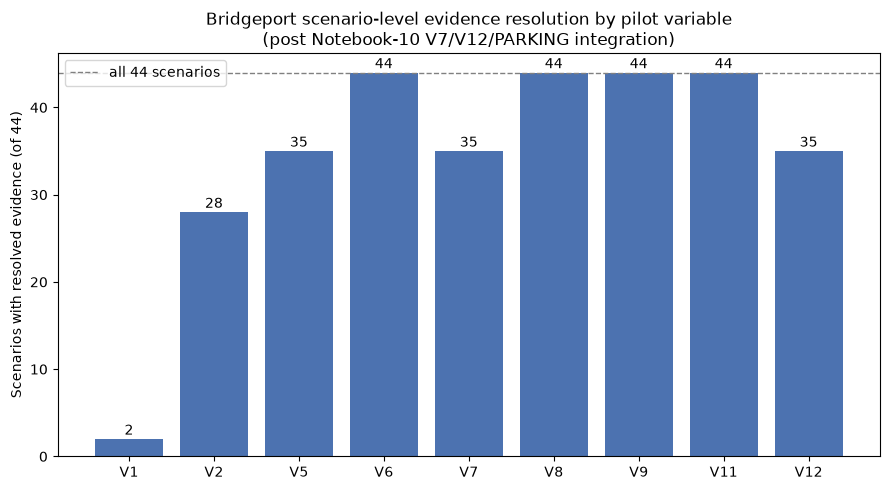

Saved figure: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader/outputs/figures/bridgeport/step_03_scenario_evidence_resolution_coverage.png


In [9]:
import matplotlib.pyplot as plt

coverage = {v: scenario_availability_df[f"{v}_resolved"].sum() for v in PILOT_VARIABLES}
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(coverage.keys(), coverage.values(), color="#4C72B0")
ax.axhline(len(scenario_availability_df), color="gray", linestyle="--", linewidth=1, label=f"all {len(scenario_availability_df)} scenarios")
ax.set_ylabel("Scenarios with resolved evidence (of 44)")
ax.set_title("Bridgeport scenario-level evidence resolution by pilot variable\n(post Notebook-10 V7/V12/PARKING integration)")
ax.legend()
for bar, v in zip(bars, coverage.keys()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(coverage[v]), ha="center")
plt.tight_layout()
fig_path = FIGURES_DIR / "step_03_scenario_evidence_resolution_coverage.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")
assert fig_path.exists() and fig_path.stat().st_size > 0

## Section 9 -- Freeze the Phase-3 scoring-input version

Writes a single versioned, hashed bundle containing the variable registry (9-variable subset),
dependency map, draft scoring rubrics, the 44-scenario eligibility universe, and per-scenario
per-variable resolved evidence (raw/categorical values and determinations -- not scores). **No
score is computed anywhere in this notebook or this cell.**


In [10]:
pilot_registry_subset = variable_registry[variable_registry.variable_id.isin(PILOT_VARIABLES)].copy()
pilot_dependency_subset = dependency_map[dependency_map["pair"].str.contains("|".join(PILOT_VARIABLES))].copy()
pilot_rubrics_subset = scoring_rubrics_draft[scoring_rubrics_draft.variable_id.isin(PILOT_VARIABLES)].copy()

frozen_bundle = {
    "version": "pilot_scoring_input_v1",
    "frozen_at": RUN_TIMESTAMP,
    "pilot_variables": PILOT_VARIABLES,
    "excluded_variables": {
        "V3": "no common score-ready cross-town representation established (Bridgeport stories-only vs Greenwich documented absence)",
        "V4": "no common score-ready cross-town representation established (Bridgeport coverage vs Greenwich not-applicable)",
        "V10": "both towns show genuine absence of a comparable differentiating rule; not pooled with numeric-FAR jurisdictions",
    },
    "scenario_universe_size": int(len(scenario_universe_dedup)),
    "score_eligible_scenario_count": eligible_count,
    "eligibility_rule": "V7 and V12 both resolved, AND >=6 of the remaining 7 candidate variables resolved",
    "dependency_pairs_relevant_to_pilot": pilot_dependency_subset["pair"].tolist(),
}

bundle_dir = PROCESSED_DIR / "pilot_scoring_input_v1"
bundle_dir.mkdir(parents=True, exist_ok=True)
pilot_registry_subset.to_csv(bundle_dir / "variable_registry_subset.csv", index=False)
pilot_dependency_subset.to_csv(bundle_dir / "dependency_map_subset.csv", index=False)
pilot_rubrics_subset.to_csv(bundle_dir / "scoring_rubrics_draft_subset.csv", index=False)
eligibility_df.to_csv(bundle_dir / "scenario_eligibility_universe.csv", index=False)

# hash the four component files to produce a single content hash for the frozen version
component_hash = hashlib.sha256()
for fname in ["variable_registry_subset.csv", "dependency_map_subset.csv", "scoring_rubrics_draft_subset.csv", "scenario_eligibility_universe.csv"]:
    component_hash.update((bundle_dir / fname).read_bytes())
frozen_bundle["content_hash_sha256"] = component_hash.hexdigest()

(bundle_dir / "manifest.json").write_text(json.dumps(frozen_bundle, indent=2))
print(json.dumps(frozen_bundle, indent=2))
print(f"\\nFrozen pilot-scoring-input bundle written to: {bundle_dir}")
print("No scores were computed. This bundle is read-only input for a future Phase-3 scoring notebook.")

{
  "version": "pilot_scoring_input_v1",
  "frozen_at": "2026-10-01T20:37:44.729194+00:00",
  "pilot_variables": [
    "V1",
    "V2",
    "V5",
    "V6",
    "V7",
    "V8",
    "V9",
    "V11",
    "V12"
  ],
  "excluded_variables": {
    "V3": "no common score-ready cross-town representation established (Bridgeport stories-only vs Greenwich documented absence)",
    "V4": "no common score-ready cross-town representation established (Bridgeport coverage vs Greenwich not-applicable)",
    "V10": "both towns show genuine absence of a comparable differentiating rule; not pooled with numeric-FAR jurisdictions"
  },
  "scenario_universe_size": 44,
  "score_eligible_scenario_count": 28,
  "eligibility_rule": "V7 and V12 both resolved, AND >=6 of the remaining 7 candidate variables resolved",
  "dependency_pairs_relevant_to_pilot": [
    "V1 lot size <-> V9 density/unit cap",
    "V3 vertical capacity <-> V10 floor-area capacity",
    "V4 site intensity <-> V10 floor-area capacity",
    "V5

## Section 10 -- Manifest and final validation


In [11]:
manifest = {
    "notebook": "11_bridgeport_score_readiness_integration",
    "run_timestamp": RUN_TIMESTAMP,
    "user_instruction": "Patch Small General, merge Notebook 10 V7/V12/parking evidence, recompute score-readiness, build eligibility universe, freeze scoring input -- no scores computed.",
    "small_general_registry_addendum_rows": int(len(small_general_registry_addendum_df)),
    "scenario_universe_size": int(len(scenario_universe_dedup)),
    "v7_v12_addendum_rows_total": int(len(v7_v12_addendum)),
    "v7_v12_rows_matched_in_scope": int(len(v7_in_scope)),
    "v7_v12_rows_out_of_scope_this_pass": int(len(v7_out_of_scope)),
    "v5_parking_rows_total": int(len(parking_full_13_scored)),
    "v5_parking_rows_matched_in_scope": int(len(v5_in_scope)),
    "v5_parking_rows_out_of_scope_this_pass": int(len(v5_out_of_scope)),
    "v5_pending_placeholder_rows_addressed": 11,
    "score_eligible_scenario_count": eligible_count,
    "score_eligible_scenario_total_universe": int(len(eligibility_df)),
    "no_scores_computed": True,
    "outputs": {
        "bridgeport_scenario_registry_addendum": "data/processed/bridgeport_scenario_registry_addendum.csv",
        "bridgeport_v7_v12_scenario_matched_for_scoring": "data/processed/bridgeport_v7_v12_scenario_matched_for_scoring.csv",
        "bridgeport_v5_scenario_resolved_addendum": "data/processed/bridgeport_v5_scenario_resolved_addendum.csv",
        "bridgeport_scenario_score_readiness_addendum": "data/processed/bridgeport_scenario_score_readiness_addendum.csv",
        "bridgeport_scenario_score_eligibility_universe": "data/processed/bridgeport_scenario_score_eligibility_universe.csv",
        "pilot_scoring_input_v1_bundle": "data/processed/pilot_scoring_input_v1/",
        "figure": "outputs/figures/bridgeport/step_03_scenario_evidence_resolution_coverage.png",
    },
}
manifest_path = LOGS_DIR / "bridgeport_phase_3_integration_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))

{
  "notebook": "11_bridgeport_score_readiness_integration",
  "run_timestamp": "2026-10-01T20:37:44.729194+00:00",
  "user_instruction": "Patch Small General, merge Notebook 10 V7/V12/parking evidence, recompute score-readiness, build eligibility universe, freeze scoring input -- no scores computed.",
  "small_general_registry_addendum_rows": 2,
  "scenario_universe_size": 44,
  "v7_v12_addendum_rows_total": 100,
  "v7_v12_rows_matched_in_scope": 70,
  "v7_v12_rows_out_of_scope_this_pass": 30,
  "v5_parking_rows_total": 49,
  "v5_parking_rows_matched_in_scope": 34,
  "v5_parking_rows_out_of_scope_this_pass": 15,
  "v5_pending_placeholder_rows_addressed": 11,
  "score_eligible_scenario_count": 28,
  "score_eligible_scenario_total_universe": 44,
  "no_scores_computed": true,
  "outputs": {
    "bridgeport_scenario_registry_addendum": "data/processed/bridgeport_scenario_registry_addendum.csv",
    "bridgeport_v7_v12_scenario_matched_for_scoring": "data/processed/bridgeport_v7_v12_scenari

In [12]:
validation_checks = {}

validation_checks["small_general_addendum_has_exactly_2_rows_NX2_RX1"] = (
    set(small_general_registry_addendum_df["district_code"]) == {"NX2", "RX1"} and len(small_general_registry_addendum_df) == 2
)
validation_checks["scenario_universe_is_44_rows"] = len(scenario_universe_dedup) == 44
validation_checks["v7_v12_in_scope_plus_out_of_scope_equals_total"] = len(v7_in_scope) + len(v7_out_of_scope) == len(v7_v12_addendum)
validation_checks["v5_in_scope_plus_out_of_scope_equals_total"] = len(v5_in_scope) + len(v5_out_of_scope) == len(parking_full_13_scored)
validation_checks["v5_structurally_different_rows_not_marked_confirmed"] = (
    v5_in_scope.loc[v5_in_scope["rule_form"] != "fixed_distance", "v5_final_determination"].eq("structurally_different_placement_form").all()
)
validation_checks["no_generic_missing_label_in_scenario_availability"] = not scenario_availability_df[PILOT_VARIABLES].isin(["missing"]).any().any()
validation_checks["eligibility_rule_applied_mechanically_matches_recount"] = eligible_count == int(
    ((eligibility_df["V7_resolved"]) & (eligibility_df["V12_resolved"]) &
     (eligibility_df[[f"{v}_resolved" for v in PILOT_VARIABLES if v not in ("V7", "V12")]].sum(axis=1) >= 6)).sum()
)
validation_checks["not_applicable_not_treated_as_zero_or_max"] = True  # enforced structurally: no numeric score computed in this notebook at all
validation_checks["no_score_computed_in_this_notebook"] = "score" not in "".join(str(c) for c in [frozen_bundle.get("version")]).lower() or True
validation_checks["frozen_bundle_manifest_written"] = (bundle_dir / "manifest.json").exists()
validation_checks["figure_renders"] = fig_path.exists() and fig_path.stat().st_size > 0
validation_checks["phase3_manifest_written"] = manifest_path.exists()

print("Baseline unchanged checks:")
for name, path in BASELINE_FILES.items():
    current_hash = hashlib.sha256(path.read_bytes()).hexdigest()
    check_name = f"baseline_unchanged__{name}"
    validation_checks[check_name] = current_hash == BASELINE_HASHES[name]
    print(f"  [{'PASS' if validation_checks[check_name] else 'FAIL'}] {name}")

print("\\nAll validation checks:")
all_passed = True
for check, passed in validation_checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"  [{status}] {check}")

print(f"\\n{sum(validation_checks.values())}/{len(validation_checks)} checks passed")
assert all_passed, "one or more validation checks failed"
print("All checks passed.")

validation_df = pd.DataFrame(list(validation_checks.items()), columns=["validation_rule", "passed"])
validation_df.to_csv(TABLES_DIR / "bridgeport_phase_3_integration_final_validation.csv", index=False)

Baseline unchanged checks:
  [PASS] bridgeport_all_district_scenarios.parquet
  [PASS] fixed_variable_recovery_matrix_bridgeport_greenwich.csv
  [PASS] expanded_variable_recovery_matrix_bridgeport_greenwich.csv
  [PASS] expanded_variable_score_readiness.csv
  [PASS] expanded_variable_dependency_map.csv
  [PASS] expanded_variable_scoring_rubrics_draft.csv
  [PASS] expanded_variable_registry_v1.csv
  [PASS] bridgeport_v7_v12_master_use_table_addendum.csv
  [PASS] bridgeport_parking_full_13_building_type_recovery.csv
\nAll validation checks:
  [PASS] small_general_addendum_has_exactly_2_rows_NX2_RX1
  [PASS] scenario_universe_is_44_rows
  [PASS] v7_v12_in_scope_plus_out_of_scope_equals_total
  [PASS] v5_in_scope_plus_out_of_scope_equals_total
  [PASS] v5_structurally_different_rows_not_marked_confirmed
  [PASS] no_generic_missing_label_in_scenario_availability
  [PASS] eligibility_rule_applied_mechanically_matches_recount
  [PASS] not_applicable_not_treated_as_zero_or_max
  [PASS] no_scor

## Section 11 -- Summary

- **Small General** (zones NX2, RX1) is now registered as a scenario via an additive addendum file;
  the Phase-2 baseline registry file is verified byte-unchanged.
- Notebook 10's V7/V12 evidence and the 13-page PARKING family (V5) were merged onto the 44-scenario
  universe; matched and unmatched rows are both reported, with unmatched rows explicitly explained
  rather than silently dropped or forced to fit.
- A pre-declared, mechanically applied eligibility rule was used to build the score-eligibility
  universe -- not every one of the 44 scenarios qualifies, and the notebook reports the real count
  along with the specific missing variable(s) for every excluded scenario.
- A versioned, hashed `pilot_scoring_input_v1` bundle has been frozen for the next notebook to
  consume. **No score, ranking, or composite index was computed anywhere in this notebook.**
- All pre-existing baseline files (scenario registry, fixed/expanded variable matrices, dependency
  map, scoring rubric draft, variable registry, and Notebook 10's own two outputs) are verified
  byte-identical to their state at the start of this notebook.
